In [2]:
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import torchvision, torchvision.transforms as transforms, torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np, copy, time, warnings
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 장치: {device}')

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']
NUM_CLASSES = 10

사용 장치: cuda


In [3]:
import matplotlib.font_manager as fm
import subprocess

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
fm._load_fontmanager(try_read_cache=False)

if any('Nanum' in f.name for f in fm.fontManager.ttflist):
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

100%|██████████| 2.64G/2.64G [01:51<00:00, 23.6MB/s]


학습: 5,000장 | 테스트: 8,000장


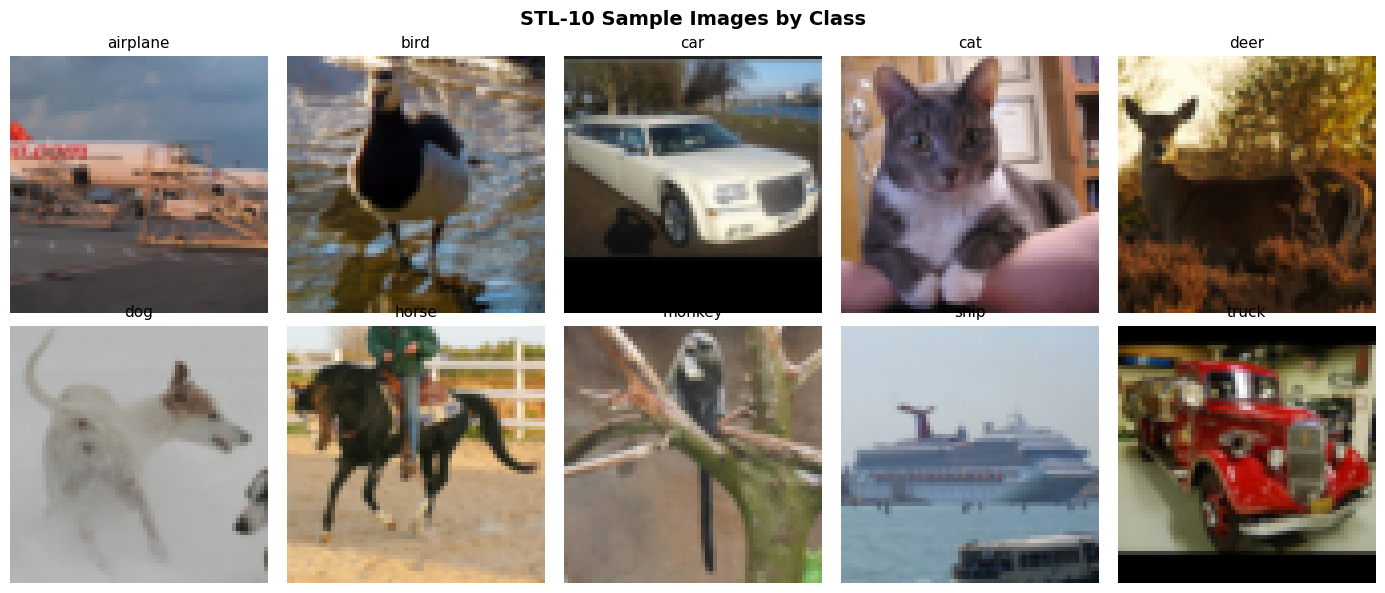

In [4]:
# STL-10 데이터셋 불러오기
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
vis_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

trainset    = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=train_transform)
testset     = torchvision.datasets.STL10(root='./data', split='test',  download=True, transform=test_transform)
vis_dataset = torchvision.datasets.STL10(root='./data', split='test',  download=False, transform=vis_transform)

CIFAR10_CLASSES = ['airplane','bird','car','cat','deer',
                   'dog','horse','monkey','ship','truck']

trainloader = DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'학습: {len(trainset):,}장 | 테스트: {len(testset):,}장')

# 클래스별 샘플 이미지 1장씩 출력
found = {}
for img, label in vis_dataset:
    if label not in found:
        found[label] = img
    if len(found) == NUM_CLASSES:
        break

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('STL-10 Sample Images by Class', fontsize=14, fontweight='bold')
for i in range(NUM_CLASSES):
    ax = axes[i // 5][i % 5]
    ax.imshow(found[i].permute(1, 2, 0).numpy())
    ax.set_title(f'{CIFAR10_CLASSES[i]}', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad() # 이전 gradient 초기화
        loss = criterion(outputs := model(inputs), labels)
        loss.backward() # 역전파 계산
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct    += outputs.max(1)[1].eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs     = model(inputs)
            total_loss += criterion(outputs, labels).item() * inputs.size(0)
            correct    += outputs.max(1)[1].eq(labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def train_phase(model, criterion, optimizer, scheduler,
                num_epochs, phase_name='Phase', history=None):
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_acc, best_weights = 0.0, copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, trainloader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, testloader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_acc:
            best_acc     = va_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f'[{phase_name}] {epoch:02d}/{num_epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | '
              f'Val Loss: {va_loss:.4f} Acc: {va_acc:.2f}%')

    model.load_state_dict(best_weights)
    print(f'\n✅ {phase_name} 완료 — 최고 Val Acc: {best_acc:.2f}%\n')
    return model, history

In [ ]:
#ResNet18 정의 및 학습
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) #기존의 ResNet18 가중치 유지
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet = resnet.to(device)

print(f'ResNet18 FC: {resnet.fc}')
print(f'학습 가능 파라미터: {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}')

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.SGD(resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
resnet_scheduler = optim.lr_scheduler.StepLR(resnet_optimizer, step_size=5, gamma=0.5)

resnet, resnet_history = train_phase(
    resnet, resnet_criterion, resnet_optimizer, resnet_scheduler,
    num_epochs=10, phase_name='ResNet Phase1'
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


ResNet18 FC: Linear(in_features=512, out_features=10, bias=True)
학습 가능 파라미터: 11,181,642
[ResNet Phase1] 01/10 | Train Loss: 0.5065 Acc: 83.28% | Val Loss: 0.4128 Acc: 86.91%
[ResNet Phase1] 02/10 | Train Loss: 0.1597 Acc: 94.48% | Val Loss: 0.4930 Acc: 85.10%
[ResNet Phase1] 03/10 | Train Loss: 0.1123 Acc: 95.98% | Val Loss: 0.2366 Acc: 92.34%
[ResNet Phase1] 04/10 | Train Loss: 0.0452 Acc: 98.52% | Val Loss: 0.2107 Acc: 93.25%
[ResNet Phase1] 05/10 | Train Loss: 0.0485 Acc: 98.64% | Val Loss: 0.2030 Acc: 93.79%
[ResNet Phase1] 06/10 | Train Loss: 0.0394 Acc: 98.98% | Val Loss: 0.1647 Acc: 94.70%
[ResNet Phase1] 07/10 | Train Loss: 0.0147 Acc: 99.72% | Val Loss: 0.1724 Acc: 94.53%
[ResNet Phase1] 08/10 | Train Loss: 0.0354 Acc: 99.00% | Val Loss: 0.1646 Acc: 94.79%
[ResNet Phase1] 09/10 | Train Loss: 0.0086 Acc: 99.86% | Val Loss: 0.1525 Acc: 95.09%
[ResNet Phase1] 10/10 | Train Loss: 0.0082 Acc: 99.88% | Val Loss: 0.1610 Acc: 95.12%

✅ ResNet Phase1 완료 — 최고 Val Acc: 95.12%



In [ ]:
# VGG16 전이학습 정의 및 학습
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1) # 기존의 Vgg 16 가중치 유지

# Conv 블록 전체 동결
for param in vgg16.features.parameters():
    param.requires_grad = False

# 마지막 분류기만 교체
vgg16.classifier[6] = nn.Linear(4096, NUM_CLASSES)
vgg16 = vgg16.to(device)

print(f'학습 가능 파라미터: {sum(p.numel() for p in vgg16.parameters() if p.requires_grad):,}')

vgg16_criterion = nn.CrossEntropyLoss()
vgg16_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=1e-4, weight_decay=1e-4
)
vgg16_scheduler = optim.lr_scheduler.StepLR(vgg16_optimizer, step_size=5, gamma=0.5)

vgg16, vgg16_history = train_phase(
    vgg16, vgg16_criterion, vgg16_optimizer, vgg16_scheduler,
    num_epochs=10, phase_name='VGG16'
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 91.5MB/s]


학습 가능 파라미터: 119,586,826
[VGG16] 01/10 | Train Loss: 0.4230 Acc: 86.56% | Val Loss: 0.1709 Acc: 94.11%
[VGG16] 02/10 | Train Loss: 0.1044 Acc: 96.36% | Val Loss: 0.1577 Acc: 94.78%
[VGG16] 03/10 | Train Loss: 0.0555 Acc: 98.08% | Val Loss: 0.1526 Acc: 95.29%
[VGG16] 04/10 | Train Loss: 0.0302 Acc: 99.10% | Val Loss: 0.1592 Acc: 95.11%
[VGG16] 05/10 | Train Loss: 0.0162 Acc: 99.46% | Val Loss: 0.1658 Acc: 94.95%
[VGG16] 06/10 | Train Loss: 0.0095 Acc: 99.84% | Val Loss: 0.1531 Acc: 95.46%
[VGG16] 07/10 | Train Loss: 0.0054 Acc: 99.88% | Val Loss: 0.1540 Acc: 95.46%
[VGG16] 08/10 | Train Loss: 0.0041 Acc: 99.88% | Val Loss: 0.1703 Acc: 95.33%
[VGG16] 09/10 | Train Loss: 0.0033 Acc: 99.90% | Val Loss: 0.1621 Acc: 95.64%
[VGG16] 10/10 | Train Loss: 0.0021 Acc: 99.98% | Val Loss: 0.1634 Acc: 95.72%

✅ VGG16 완료 — 최고 Val Acc: 95.72%



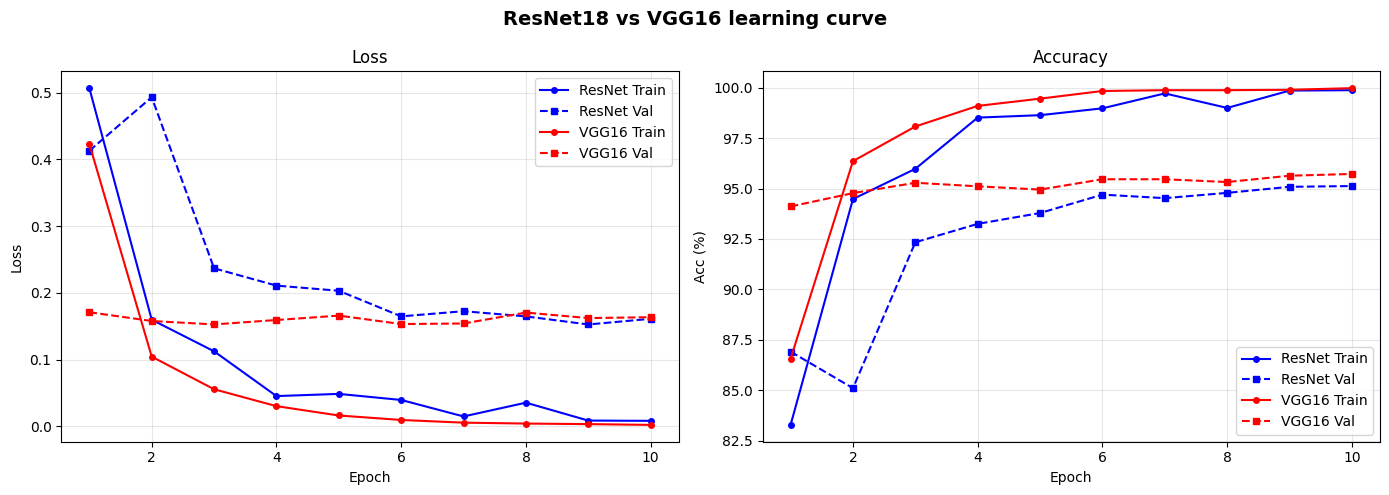

In [8]:
epochs = list(range(1, 11))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet vs VGG16 learning curve', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, resnet_history['train_loss'][-10:], 'b-o', ms=4, label='ResNet Train')
axes[0].plot(epochs, resnet_history['val_loss'][-10:],   'b--s', ms=4, label='ResNet Val')
axes[0].plot(epochs, vgg16_history['train_loss'],  'r-o', ms=4, label='VGG16 Train')
axes[0].plot(epochs, vgg16_history['val_loss'],    'r--s', ms=4, label='VGG16 Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, resnet_history['train_acc'][-10:], 'b-o', ms=4, label='ResNet Train')
axes[1].plot(epochs, resnet_history['val_acc'][-10:],   'b--s', ms=4, label='ResNet Val')
axes[1].plot(epochs, vgg16_history['train_acc'],  'r-o', ms=4, label='VGG16 Train')
axes[1].plot(epochs, vgg16_history['val_acc'],    'r--s', ms=4, label='VGG16 Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

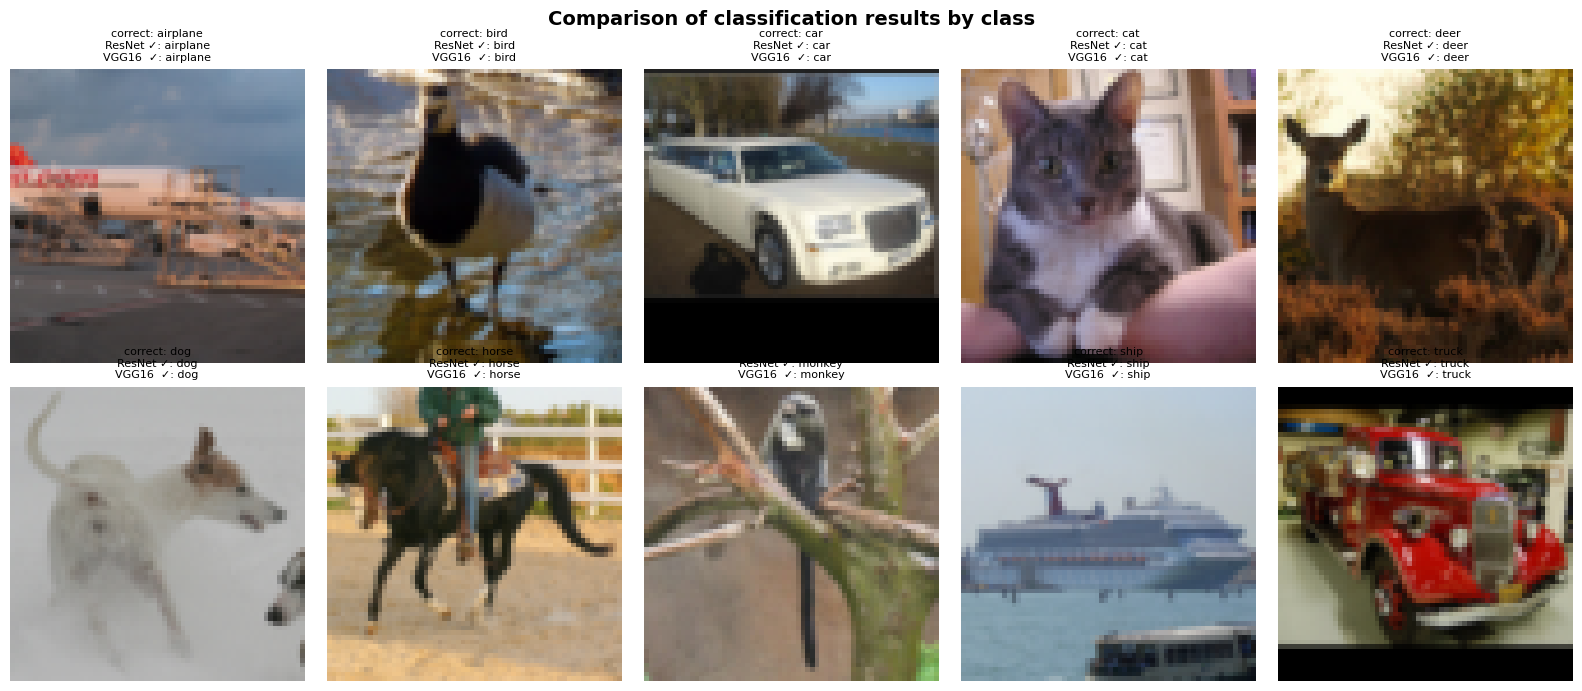

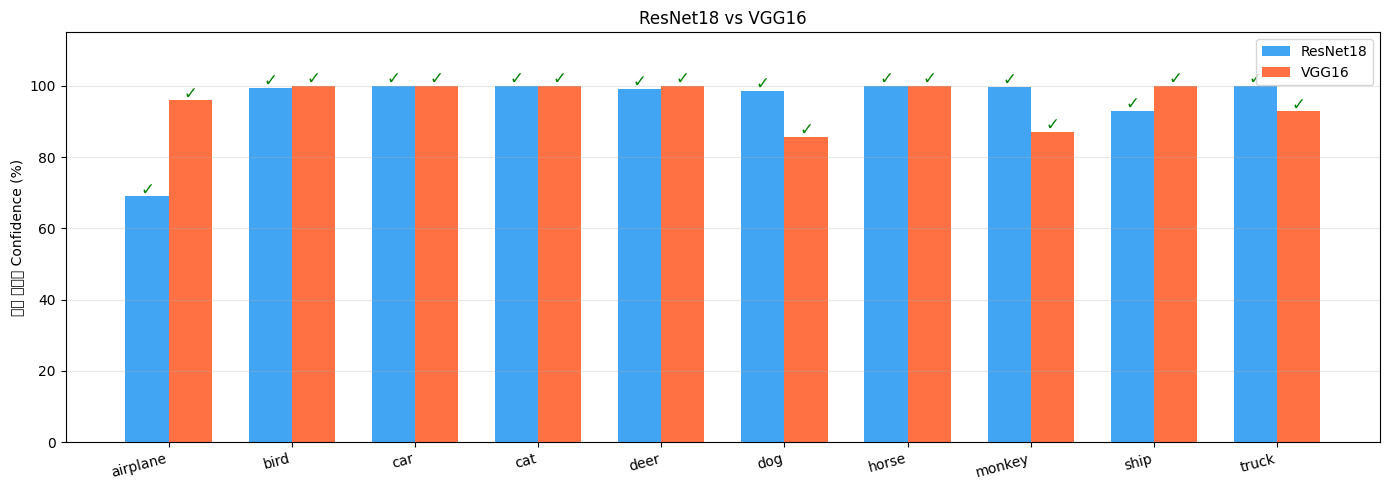

ResNet18 정답: 10/10
VGG16    정답: 10/10


In [9]:
# 클래스별 분류 결과 비교 (이미지 + 막대차트)
def get_preds(model, images_tensor):
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(images_tensor.to(device)), dim=1).cpu().numpy()
    return probs.argmax(axis=1), probs

# 클래스별 대표 이미지 1장씩 출력
found = {}
for img, label in vis_dataset:
    if label not in found:
        found[label] = (img, label)
    if len(found) == NUM_CLASSES:
        break

imgs_vis   = [found[i][0] for i in range(NUM_CLASSES)]
imgs_model = torch.stack([
    test_transform(torchvision.transforms.ToPILImage()(found[i][0]))
    for i in range(NUM_CLASSES)
])
true_labels = [found[i][1] for i in range(NUM_CLASSES)]

resnet_preds, resnet_probs = get_preds(resnet, imgs_model)
vgg16_preds,  vgg16_probs  = get_preds(vgg16,  imgs_model)

# 이미지 + 예측 결과
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Comparison of classification results by class', fontsize=14, fontweight='bold')
for i in range(NUM_CLASSES):
    ax = axes[i // 5][i % 5]
    ax.imshow(imgs_vis[i].permute(1, 2, 0).numpy())
    r_ok = '✓' if resnet_preds[i] == true_labels[i] else '✗'
    v_ok = '✓' if vgg16_preds[i]  == true_labels[i] else '✗'
    ax.set_title(
        f'correct: {CIFAR10_CLASSES[true_labels[i]]}\n'
        f'ResNet {r_ok}: {CIFAR10_CLASSES[resnet_preds[i]]}\n'
        f'VGG16  {v_ok}: {CIFAR10_CLASSES[vgg16_preds[i]]}',
        fontsize=8
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

# 정답 클래스 confidence 막대차트
fig, ax = plt.subplots(figsize=(14, 5))
x, w = np.arange(NUM_CLASSES), 0.35
b1 = ax.bar(x - w/2, [resnet_probs[i][true_labels[i]] * 100 for i in range(NUM_CLASSES)],
            w, label='ResNet18', color='#2196F3', alpha=0.85)
b2 = ax.bar(x + w/2, [vgg16_probs[i][true_labels[i]]  * 100 for i in range(NUM_CLASSES)],
            w, label='VGG16',    color='#FF5722', alpha=0.85)

for i, (bar1, bar2) in enumerate(zip(b1, b2)):
    for bar, pred in [(bar1, resnet_preds[i]), (bar2, vgg16_preds[i])]:
        mark  = '✓' if pred == true_labels[i] else '✗'
        color = 'green' if pred == true_labels[i] else 'red'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                mark, ha='center', fontsize=12, color=color, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(CIFAR10_CLASSES, rotation=15, ha='right')
ax.set_ylabel('정답 클래스 Confidence (%)'); ax.set_ylim(0, 115)
ax.set_title('ResNet18 vs VGG16')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ResNet18 정답: {sum(resnet_preds[i] == true_labels[i] for i in range(10))}/10')
print(f'VGG16    정답: {sum(vgg16_preds[i]  == true_labels[i] for i in range(10))}/10')

## 4.가상 데이터셋을 생성한 뒤, GridSearch와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요.

학습: (800, 20) | 테스트: (200, 20)
클래스 분포: [265 269 266]


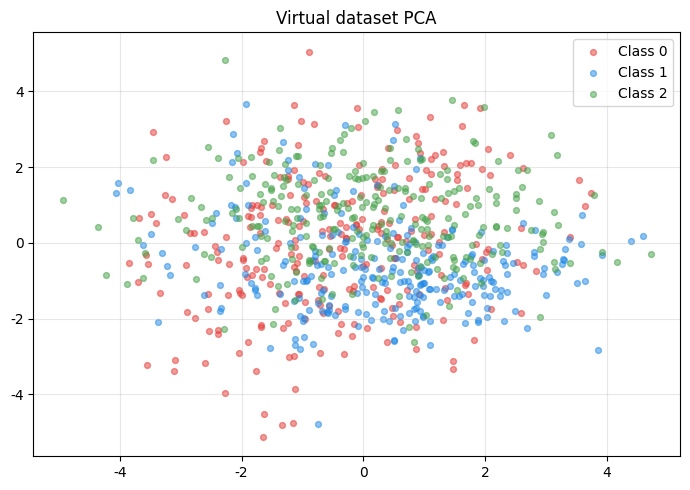

In [11]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from scipy.stats import randint as sp_randint
import pandas as pd

np.random.seed(42)

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=3,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'학습: {X_train.shape} | 테스트: {X_test.shape}')
print(f'클래스 분포: {np.bincount(y_train)}')

# PCA 시각화
X_vis = PCA(n_components=2).fit_transform(X_train)
fig, ax = plt.subplots(figsize=(7, 5))
for cls, color in enumerate(['#E53935', '#1E88E5', '#43A047']):
    mask = y_train == cls
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c=color, label=f'Class {cls}', alpha=0.5, s=18)
ax.set_title('Virtual dataset PCA')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
#GridSearchCV
import time

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, return_train_score=True
)

t0 = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - t0

grid_test_acc = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f'소요시간   : {grid_time:.1f}초')
print(f'최적 파라미터: {grid_search.best_params_}')
print(f'CV Accuracy  : {grid_search.best_score_*100:.2f}%')
print(f'Test Accuracy: {grid_test_acc*100:.2f}%')

소요시간   : 76.3초
최적 파라미터: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
CV Accuracy  : 79.50%
Test Accuracy: 79.00%


In [13]:
# RandomizedSearchCV
param_dist = {
    'n_estimators'     : sp_randint(50, 400),
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': sp_randint(2, 20),
    'min_samples_leaf' : sp_randint(1, 10),
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist, n_iter=50, cv=3, scoring='accuracy',
    n_jobs=-1, random_state=42, return_train_score=True
)

t0 = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - t0

rand_test_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f'소요시간   : {random_time:.1f}초')
print(f'최적 파라미터: {random_search.best_params_}')
print(f'CV Accuracy  : {random_search.best_score_*100:.2f}%')
print(f'Test Accuracy: {rand_test_acc*100:.2f}%')

소요시간   : 119.5초
최적 파라미터: {'max_depth': 15, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 280}
CV Accuracy  : 78.51%
Test Accuracy: 76.50%


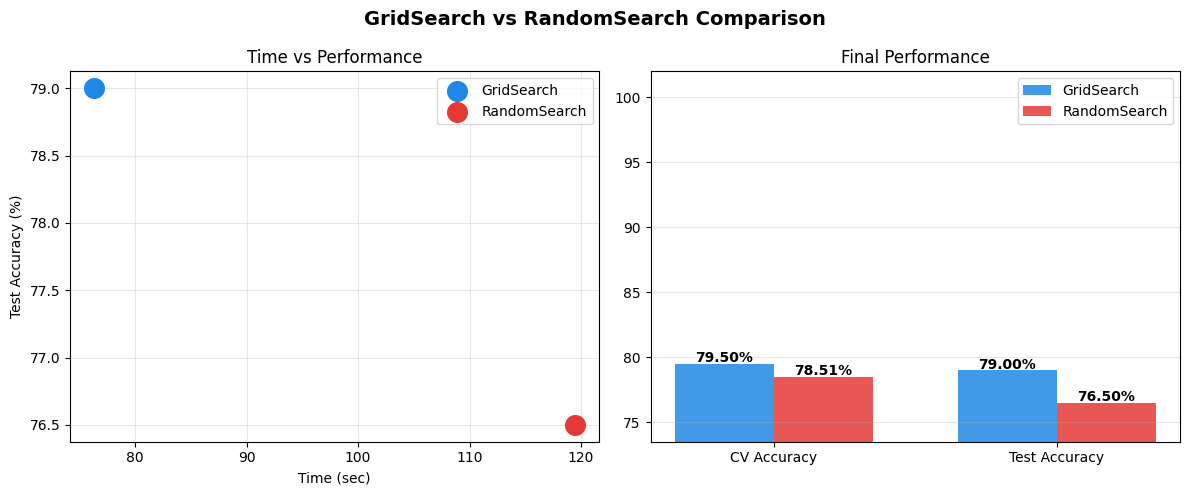

GridSearch   — combinations: 72  time: 76.3s  Test Acc: 79.00%
RandomSearch — combinations: 50         time: 119.5s  Test Acc: 76.50%


In [27]:
# [Cell 11] 결과 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GridSearch vs RandomSearch Comparison', fontsize=14, fontweight='bold')

# Time vs Accuracy
axes[0].scatter(grid_time,   grid_test_acc*100,  s=200, color='#1E88E5', zorder=5, label='GridSearch')
axes[0].scatter(random_time, rand_test_acc*100,  s=200, color='#E53935', zorder=5, label='RandomSearch')
axes[0].set_xlabel('Time (sec)'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Time vs Performance')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Final performance
x, w = np.arange(2), 0.35
g_vals = [grid_search.best_score_*100, grid_test_acc*100]
r_vals = [random_search.best_score_*100, rand_test_acc*100]
b1 = axes[1].bar(x - w/2, g_vals, w, label='GridSearch',   color='#1E88E5', alpha=0.85)
b2 = axes[1].bar(x + w/2, r_vals, w, label='RandomSearch', color='#E53935', alpha=0.85)
for bar, val in zip(list(b1)+list(b2), g_vals+r_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(['CV Accuracy', 'Test Accuracy'])
axes[1].set_title('Final Performance')
axes[1].set_ylim(min(g_vals+r_vals)-3, 102)
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'GridSearch   — combinations: {3*4*3*2}  time: {grid_time:.1f}s  Test Acc: {grid_test_acc*100:.2f}%')
print(f'RandomSearch — combinations: 50         time: {random_time:.1f}s  Test Acc: {rand_test_acc*100:.2f}%')